In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [44]:
# load the data
data = pd.read_csv('diabetes_dataset.csv')

In [3]:
data.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

##### As Per The EDA Droping Fertures that has high correlation.

a) Cholesterol features

ldl_cholesterol and cholesterol_total correlation = 0.91 → redundant.

Drop one (e.g., cholesterol_total) because ldl_cholesterol is more specific.

b) BMI and Waist-to-Hip Ratio

Correlation = 0.77 → high correlation.

Drop one (commonly bmi if waist-to-hip ratio is more predictive for cardiovascular risk).

c) HBA1c and Insulin Level

Correlation = 0.70 → moderate.

Can keep both, as they provide complementary info for diabetes prediction.

d) Diabetes Risk Score

If you are predicting diabetes, this feature may leak the target, because it’s derived from other features.

Drop diabetes_risk_score if predicting diagnosed_diabetes.

In [45]:
#Remove any Higly correlated features as per EDA analysis
data = data.drop(columns=['diabetes_stage','diabetes_risk_score','cholesterol_total','bmi'])
    

Removing highly correlated features reduces multicollinearity, which improves model stability for linear models.
For tree-based models, it’s less critical, but still helps reduce noise and improves interpretability.


#### Spliit Data to  train on one part and test on unseen data.

In [46]:
# Spliit Data to  train on one part and test on unseen data.
X = data.drop('diagnosed_diabetes', axis=1)
y = data['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Try to Exacute Decion Tree with out Encoding data since Trees Algorithms Trees split data based on thresholds so they do not assume numeric order.}

In [6]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

ValueError: could not convert string to float: 'Female'

Evan though Tree algorthms like [Decision Tree / Random Forest] not needed to encode catagorical fertures to numarical since using scikit-learn we  must still need to  convert categorical text into  numbers

#### One Hot Encode Data

In [47]:
## One Hot Encode Data
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

##### Decision Tree Clasifier

In [48]:
## Decision Tree Classifier with Encoded Data
dt_classifier_encoded = DecisionTreeClassifier(random_state=42)
dt_classifier_encoded.fit(X_train_encoded, y_train)
y_pred_dt_encoded = dt_classifier_encoded.predict(X_test_encoded)
print("Decision Tree Classifier with Encoded Data Accuracy:", accuracy_score(y_test, y_pred_dt_encoded))
print(classification_report(y_test, y_pred_dt_encoded))

Decision Tree Classifier with Encoded Data Accuracy: 0.86295
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      8000
           1       0.88      0.89      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



Confusion Matrix:
 [[ 6548  1452]
 [ 1289 10711]]


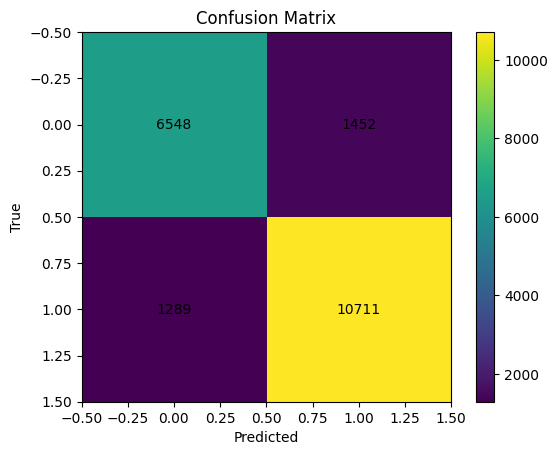

In [49]:
# Decision Tree Confusion Metrics
cm = confusion_matrix(y_test,y_pred_dt_encoded)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

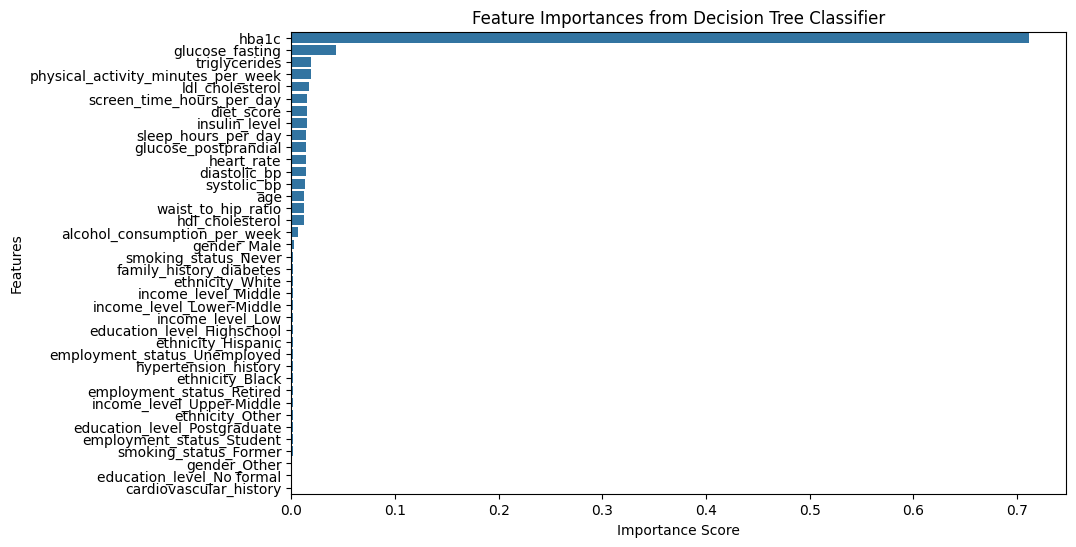

In [50]:
# Decision Tree Ferture Importance
feature_importances = pd.Series(dt_classifier_encoded.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances from Decision Tree Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

#### Random Forest Classifier

In [51]:
## Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_encoded, y_train)
y_pred_rf = rf_classifier.predict(X_test_encoded)
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Accuracy: 0.9196
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



Confusion Matrix:
 [[ 7994     6]
 [ 1602 10398]]


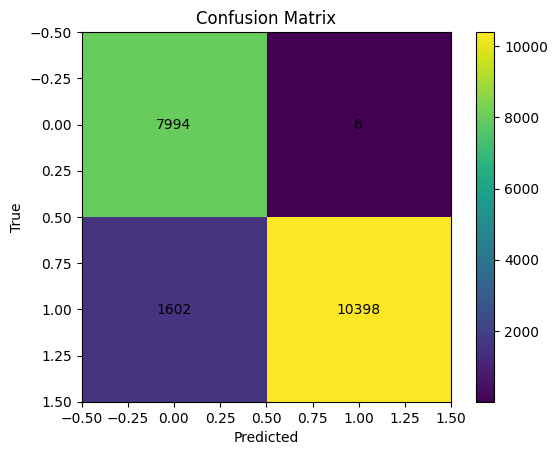

In [52]:
# Random Forest Confusion Metrics
cm = confusion_matrix(y_test,y_pred_rf)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

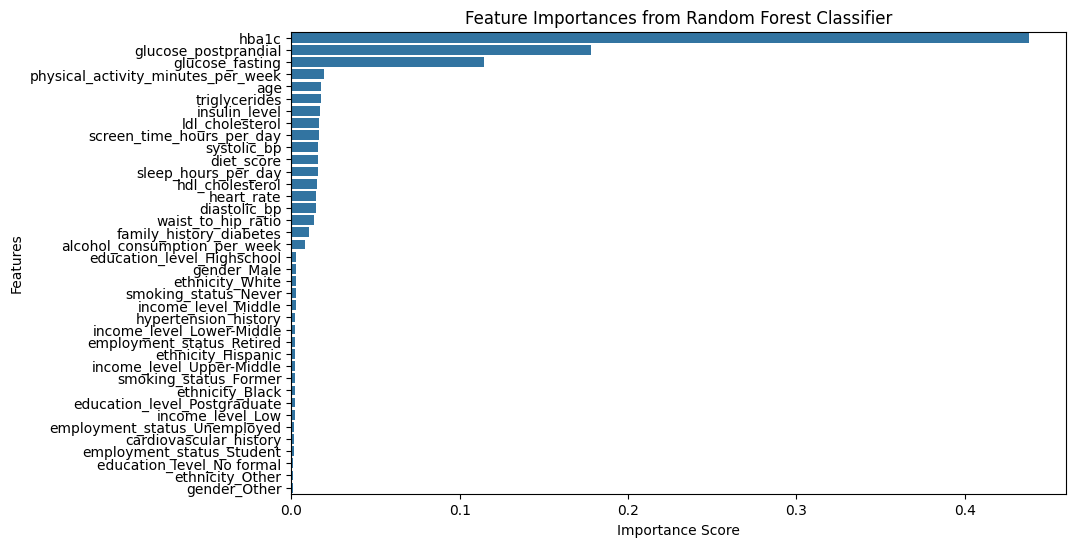

In [53]:
# random forest feature importance
rf_feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_encoded.columns)
rf_feature_importances = rf_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_feature_importances, y=rf_feature_importances.index)
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

#### Logistic Regression Classifier 

In [55]:
## Logistic Regression Classifier
logreg_classifier = LogisticRegression(max_iter=1000, random_state=42)
logreg_classifier.fit(X_train_scaled, y_train)
y_pred_logreg = logreg_classifier.predict(X_test_scaled)
print("Logistic Regression Classifier Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Classifier Accuracy: 0.86045
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      8000
           1       0.88      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



Confusion Matrix:
 [[ 6470  1530]
 [ 1261 10739]]


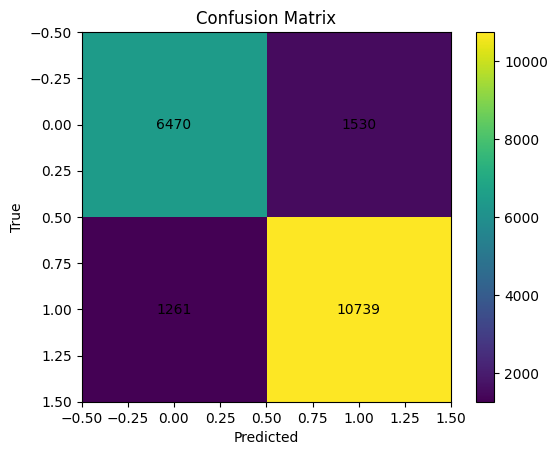

In [56]:
# Logistic Regression Confusion Metrics
cm = confusion_matrix(y_test,y_pred_logreg)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

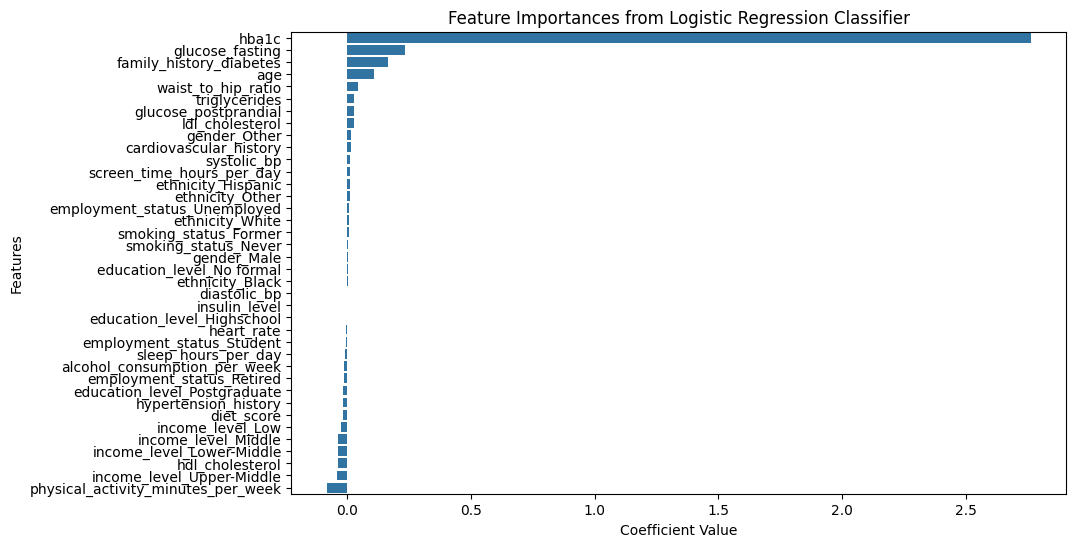

In [57]:
## logistic regression feature importance
logreg_feature_importances = pd.Series(logreg_classifier.coef_[0], index=X_train_encoded.columns)
logreg_feature_importances = logreg_feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=logreg_feature_importances, y=logreg_feature_importances.index)
plt.title('Feature Importances from Logistic Regression Classifier')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

### K-NN Model Fiting 

In [58]:
## K-NN Model Fiting 
knn = KNeighborsClassifier(n_neighbors=5)  # you can tune k later
knn.fit(X_train_scaled, y_train)

# 3. Make predictions
y_pred_Knn = knn.predict(X_test_scaled)

# 4. Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred_Knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_Knn))

Accuracy: 0.77935

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.72      0.72      8000
           1       0.81      0.82      0.82     12000

    accuracy                           0.78     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.78      0.78      0.78     20000



Confusion Matrix:
 [[5740 2260]
 [2153 9847]]


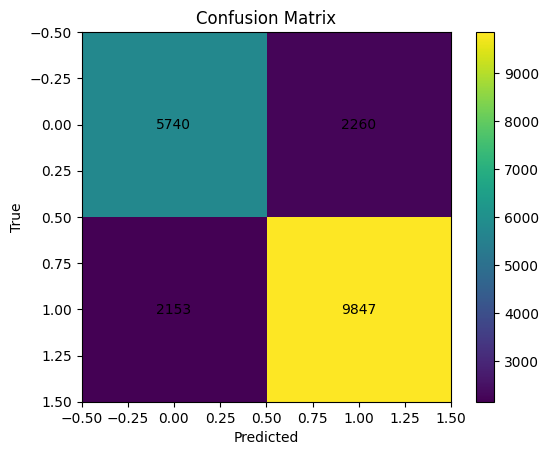

In [59]:
# KNN Regression Confusion Metrics
cm = confusion_matrix(y_test,y_pred_Knn)
print("Confusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

# Annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

/workspaces/MyMSCAssignments/AssignmentEnv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


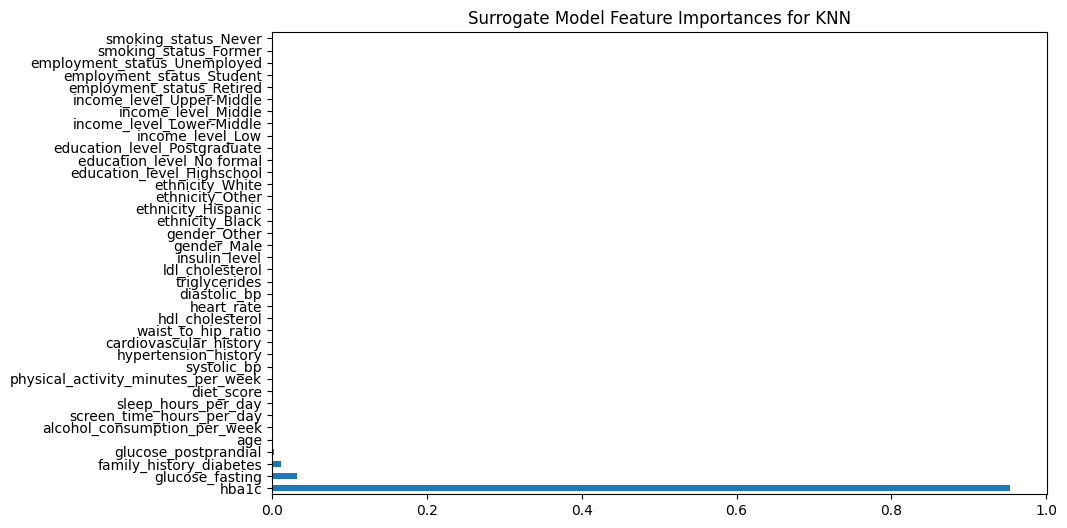

In [60]:
# Convert to DataFrame with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)

# Train surrogate model
surrogate = DecisionTreeClassifier(max_depth=5)
surrogate.fit(X_train_scaled_df, knn.predict(X_train_scaled_df))

# Create importances series
importances = pd.Series(surrogate.feature_importances_, index=X_train_scaled_df.columns)

# Plot
importances.sort_values(ascending=False).plot(kind="barh", figsize=(10, 6))
plt.title("Surrogate Model Feature Importances for KNN")
plt.show()

### Final Model Selection For The Given Data

In [61]:
# Model Comparison
models = {
    'Decision Tree': accuracy_score(y_test, y_pred_dt_encoded),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Logistic Regression': accuracy_score(y_test, y_pred_logreg),
    'KNN Clasifier':accuracy_score(y_test, y_pred_Knn)
    
}
print("Model Comparison (Accuracy Scores):")
for model, accuracy in models.items():
    print(f"{model}: {accuracy:.4f}")

Model Comparison (Accuracy Scores):
Decision Tree: 0.8629
Random Forest: 0.9196
Logistic Regression: 0.8605
KNN Clasifier: 0.7793


In [62]:
# Model Comparison Usinfg F1 Score
from sklearn.metrics import f1_score
f1_scores = {
    'Decision Tree': f1_score(y_test, y_pred_dt_encoded),
    'Random Forest': f1_score(y_test, y_pred_rf),
    'Logistic Regression': f1_score(y_test, y_pred_logreg),
    'KNN Clasifier':f1_score(y_test, y_pred_Knn)
}
print("\nModel Comparison (F1 Scores):")
for model, f1 in f1_scores.items():
    print(f"{model}: {f1:.4f}")


Model Comparison (F1 Scores):
Decision Tree: 0.8866
Random Forest: 0.9282
Logistic Regression: 0.8850
KNN Clasifier: 0.8169


In [64]:
# Model Comparison Using ROC AUC Score
roc_auc_scores = {
    'Decision Tree': roc_auc_score(y_test, dt_classifier_encoded.predict_proba(X_test_encoded)[:,1]),
    'Random Forest': roc_auc_score(y_test, rf_classifier.predict_proba(X_test_encoded)[:,1]),
    'Logistic Regression': roc_auc_score(y_test, logreg_classifier.predict_proba(X_test_scaled)[:,1]),
    'KNN Classifier': roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1])
}
print("\nModel Comparison (ROC AUC Scores):")
for model, roc_auc in roc_auc_scores.items():
    print(f"{model}: {roc_auc:.4f}")


Model Comparison (ROC AUC Scores):
Decision Tree: 0.8555
Random Forest: 0.9410
Logistic Regression: 0.9338
KNN Classifier: 0.8485


In [65]:

# Take top 10 from each
top_n = 10
lr_top = logreg_feature_importances.sort_values(ascending=False).head(top_n)
rf_top = rf_feature_importances.sort_values(ascending=False).head(top_n)
KNN_top = importances.sort_values(ascending=False).head(top_n)

# Get union of all feature names
all_features = set(lr_top.index) | set(rf_top.index) 

# Reindex each Series to have the same index (fill missing with 0)
lr_top = lr_top.reindex(all_features, fill_value=0)
rf_top = rf_top.reindex(all_features, fill_value=0)
KNN_top = KNN_top.reindex(all_features, fill_value=0)
# Combine into a DataFrame
importance_df = pd.DataFrame({
    "Logistic_Regression": lr_top,
    "Random_Forest": rf_top,
    "KNN" : KNN_top
    
})

importance_df

,Logistic_Regression,Random_Forest,KNN
glucose_postprandial,0.027317,0.177970,0.002720
triglycerides,0.028921,0.017463,0.000000
ldl_cholesterol,0.025125,0.016613,0.000000
systolic_bp,0.000000,0.016082,0.000000
screen_time_hours_per_day,0.000000,0.016588,0.000000
glucose_fasting,0.233048,0.114198,0.032603
physical_activity_minutes_per_week,0.000000,0.019459,0.000000
insulin_level,0.000000,0.016900,0.000000
age,0.107693,0.017828,0.000536
cardiovascular_history,0.013653,0.000000,0.000000


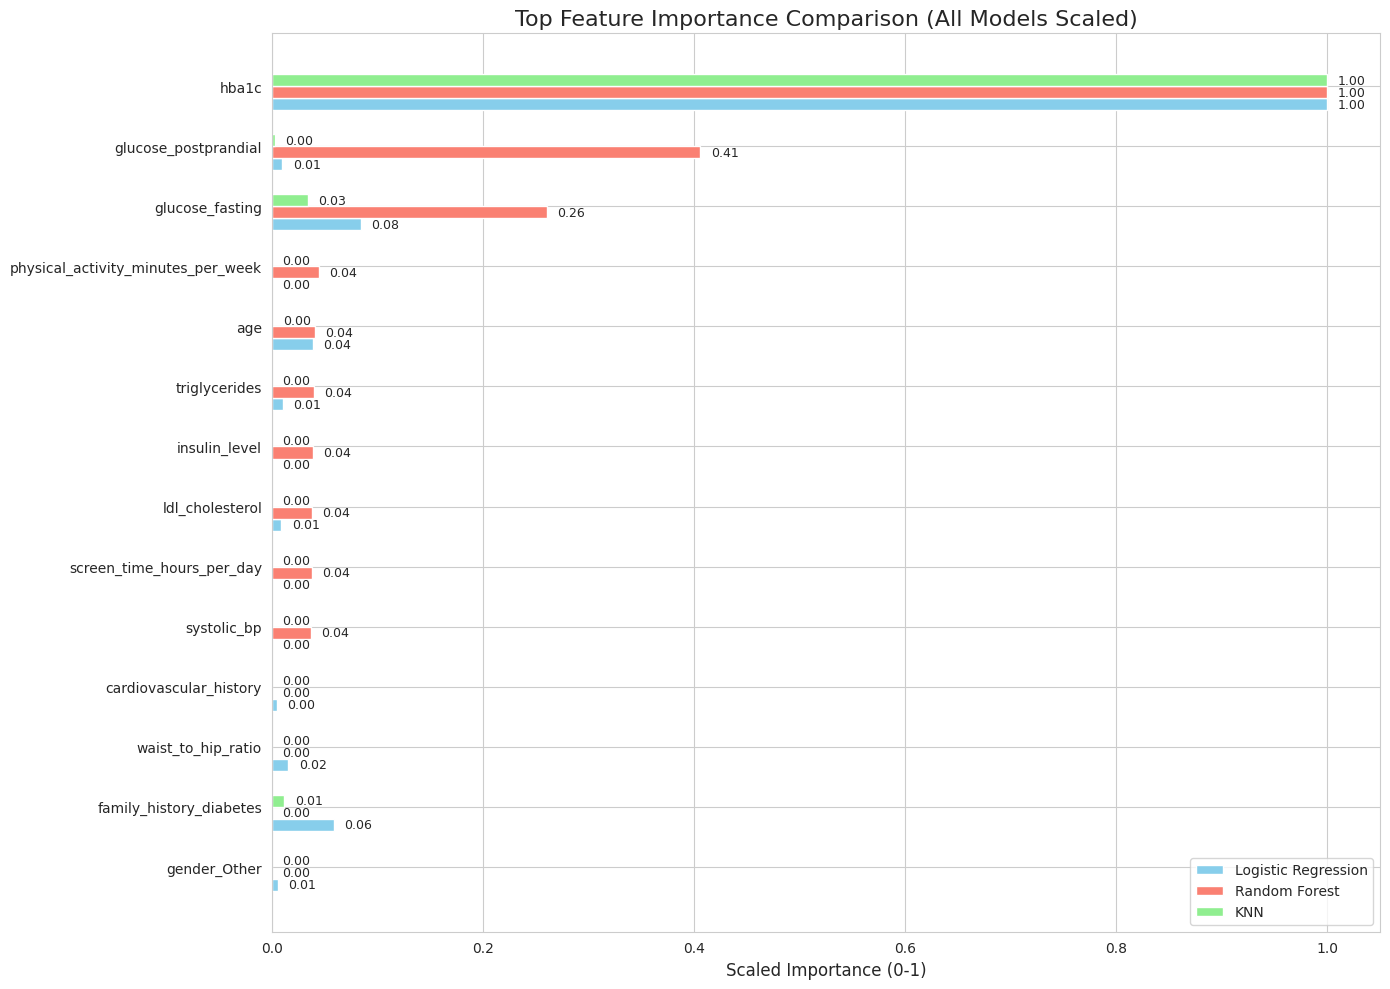

In [68]:
# Scale each model's importance to [0,1] for comparability
importance_df_scaled = importance_df.copy()
importance_df_scaled["Logistic_Regression"] = importance_df_scaled["Logistic_Regression"] / importance_df_scaled["Logistic_Regression"].max()
importance_df_scaled["Random_Forest"] = importance_df_scaled["Random_Forest"] / importance_df_scaled["Random_Forest"].max()
importance_df_scaled["KNN"] = importance_df_scaled["KNN"] / importance_df_scaled["KNN"].max()


# Sort features by Random Forest (or any model) for better visualization
importance_df_sorted = importance_df_scaled.sort_values(by="Random_Forest", ascending=True)

# Horizontal bar positions
y_pos = np.arange(len(importance_df_sorted))
height = 0.2  # bar thickness

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

# Logistic Regression
plt.barh(y_pos - 1.5*height, 
         importance_df_sorted["Logistic_Regression"], 
         height=height, 
         color='skyblue', 
         label='Logistic Regression')

# Random Forest
plt.barh(y_pos - 0.5*height, 
         importance_df_sorted["Random_Forest"], 
         height=height, 
         color='salmon', 
         label='Random Forest')

# KNN
plt.barh(y_pos + 0.5*height, 
         importance_df_sorted["KNN"], 
         height=height, 
         color='lightgreen', 
         label='KNN')



# Add data labels
for i, (lr_val, rf_val, KNN_val) in enumerate(zip(
    importance_df_sorted["Logistic_Regression"],
    importance_df_sorted["Random_Forest"],
    importance_df_sorted["KNN"]
)):
    plt.text(lr_val + 0.01, i - 1.5*height, f'{lr_val:.2f}', va='center', fontsize=9)
    plt.text(rf_val + 0.01, i - 0.5*height, f'{rf_val:.2f}', va='center', fontsize=9)
    plt.text(KNN_val + 0.01, i + 0.5*height, f'{KNN_val:.2f}', va='center', fontsize=9)

# Set y-ticks and labels
plt.yticks(y_pos, importance_df_sorted.index)
plt.xlabel("Scaled Importance (0-1)", fontsize=12)
plt.title("Top Feature Importance Comparison (All Models Scaled)", fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
model_predictions = {
    "KNN": y_pred_Knn,
    "Decision Tree": y_pred_dt_encoded,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_logreg
}

# Initialize empty list to store metrics
metrics_list = []

# Loop through each model and calculate metrics
for model_name, y_pred in model_predictions.items():
    metrics = {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    }
    metrics_list.append(metrics)

# Create a DataFrame
metrics_df = pd.DataFrame(metrics_list)

# Display the table
metrics_df


,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.7793,0.8133,0.8206,0.8169
1,Decision Tree,0.8629,0.8806,0.8926,0.8866
2,Random Forest,0.9196,0.9994,0.8665,0.9282
3,Logistic Regression,0.8605,0.8753,0.8949,0.8850


### Cross Validation For All the Models 

In [71]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [72]:
models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN":KNeighborsClassifier(n_neighbors=5)

}

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [74]:
# Store results
cv_results_list = []

for name, model in models.items():
    print(f"Running CV for {name}...")
    
    # Accuracy
    acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    
    # F1 Score
    f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    
    # ROC-AUC
    roc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    
    # Append as dict to list
    cv_results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1": f1,
        "ROC_AUC": roc
    })

# Convert list of dicts to DataFrame
cv_results = pd.DataFrame(cv_results_list)
cv_results


Running CV for Logistic_Regression...
Running CV for Random_Forest...
Running CV for KNN...


,Model,Accuracy,F1,ROC_AUC
0,Logistic_Regression,0.8589,0.883786,0.933982
1,Random_Forest,0.9213,0.929827,0.943344
2,KNN,0.7797,0.817727,0.847290


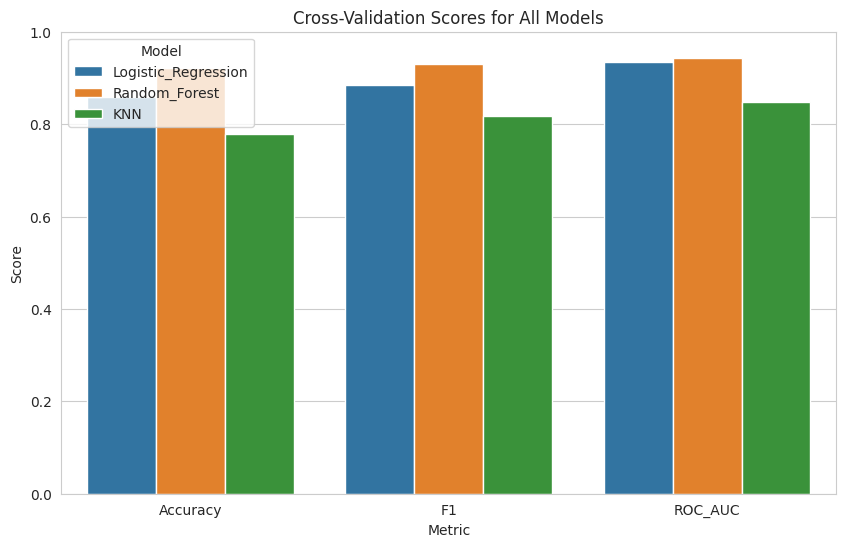

In [75]:
cv_results_melted = cv_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(x="Metric", y="Score", hue="Model", data=cv_results_melted)
plt.title("Cross-Validation Scores for All Models")
plt.ylim(0,1)
plt.ylabel("Score")
plt.show()